### IPL 2025 Performance Analysis & Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [3]:
data = pd.read_csv("IPL 2025.csv")

In [4]:
data.head(-5)

,Match Number,Date & Time,Venue,Team 1,Team 1 Score,Team 2,Team 2 Score,winner,winning_margin
0,1,"MAR, SAT 22 , 7:30 pm IST","Eden Gardens,",Kolkata Knight Riders,174/8,Royal Challengers Bengaluru,177/3,ROYAL CHALLENGERS BENGALURU,7 WICKETS
1,2,"MAR, SUN 23 , 3:30 pm IST","Rajiv Gandhi International Stadium,",Sunrisers Hyderabad,286/6,Rajasthan Royals,242/6,SUNRISERS HYDERABAD,44 RUNS
2,3,"MAR, SUN 23 , 7:30 pm IST","MA Chidambaram Stadium,",Chennai Super Kings,158/6,Mumbai Indians,155/9,CHENNAI SUPER KINGS,4 WICKETS
3,4,"MAR, MON 24 , 7:30 pm IST","Dr YS Rajasekhara Reddy ACA-VDCA Cricket Stadium,",Delhi Capitals,211/9,Lucknow Super Giants,209/8,DELHI CAPITALS,1 WICKET
4,5,"MAR, TUE 25 , 7:30 pm IST","Narendra Modi Stadium,",Gujarat Titans,232/5,Punjab Kings,243/5,PUNJAB KINGS,11 RUNS
...,...,...,...,...,...,...,...,...,...
64,65,"MAY, FRI 23 , 7:30 pm IST",Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Royal Challengers Bengaluru,189,Sunrisers Hyderabad,231/6,SUNRISERS HYDERABAD,42 RUNS
65,66,"MAY, SAT 24 , 7:30 pm IST","Sawai Mansingh Stadium,",Punjab Kings,206/8,Delhi Capitals,208/4,DELHI CAPITALS,6 WICKETS
66,67,"MAY, SUN 25 , 3:30 pm IST","Narendra Modi Stadium,",Gujarat Titans,147,Chennai Super Kings,230/5,CHENNAI SUPER KINGS,83 RUNS
67,68,"MAY, SUN 25 , 7:30 pm IST","Arun Jaitley Stadium,",Sunrisers Hyderabad,278/3,Kolkata Knight Riders,168,SUNRISERS HYDERABAD,110 RUNS


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Match Number    74 non-null     int64
 1   Date & Time     74 non-null     str  
 2   Venue           74 non-null     str  
 3   Team 1          74 non-null     str  
 4   Team 1 Score    73 non-null     str  
 5   Team 2          74 non-null     str  
 6   Team 2 Score    72 non-null     str  
 7   winner          73 non-null     str  
 8   winning_margin  74 non-null     str  
dtypes: int64(1), str(8)
memory usage: 5.3 KB


### Most Wins by Team in IPL 2025

In [6]:
temp = pd.DataFrame({"winner":data['winner']})
count_wins = temp.value_counts()
print(count_wins)
labels = [X[0] for X in count_wins.keys()]



winner                     
ROYAL CHALLENGERS BENGALURU    11
PUNJAB KINGS                   10
GUJARAT TITANS                 10
MUMBAI INDIANS                 10
DELHI CAPITALS                  7
SUNRISERS HYDERABAD             6
LUCKNOW SUPER GIANTS            6
KOLKATA KNIGHT RIDERS           5
CHENNAI SUPER KINGS             4
RAJASTHAN ROYALS                4
Name: count, dtype: int64


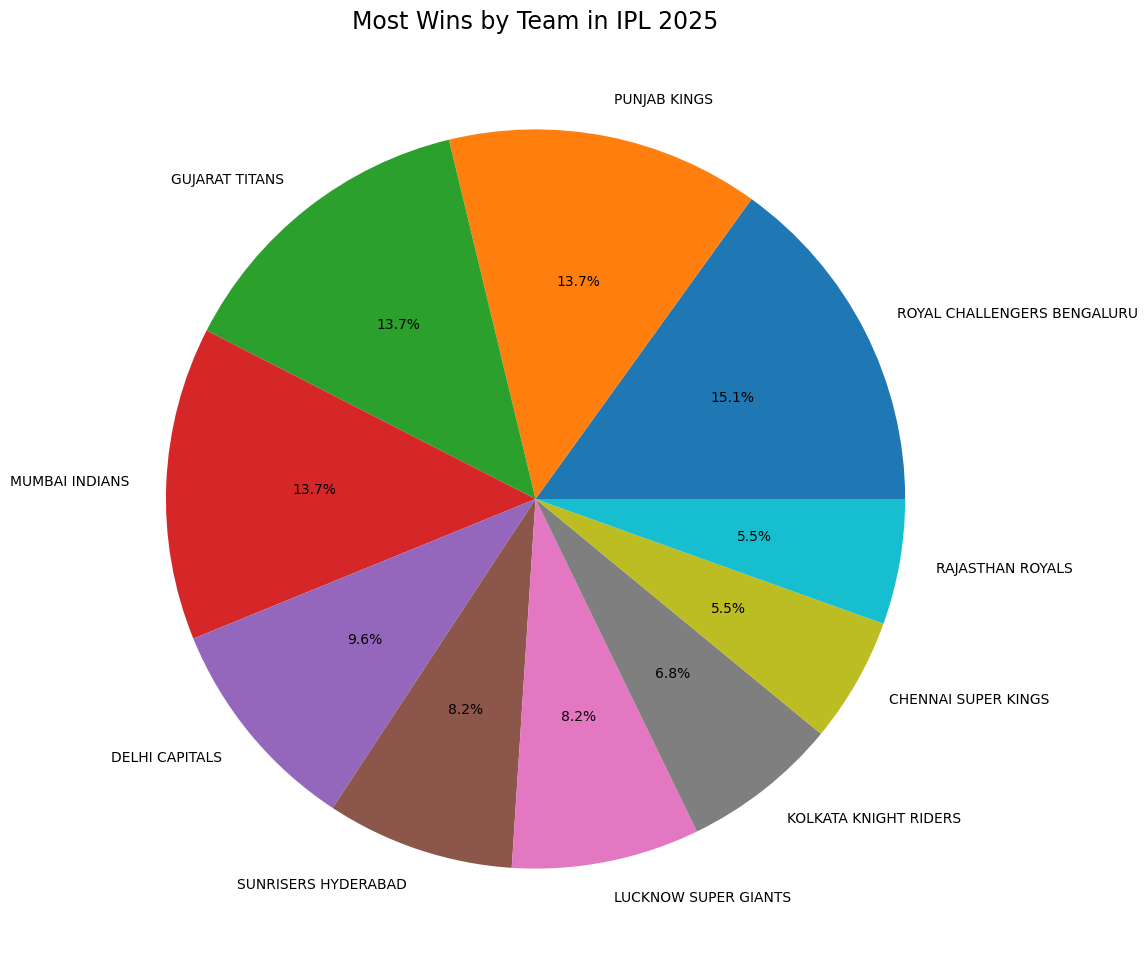

In [7]:
temp = pd.DataFrame({"winner":data['winner']})
count_wins = temp.value_counts()
labels = [X[0] for X in count_wins.keys()]

bar, ax = plt.subplots(figsize=(20,12))
ax = plt.pie(x = count_wins, autopct = "%.1f%%", labels= labels)
plt.title("Most Wins by Team in IPL 2025", fontsize = 17)
plt.show()


### Count Matches Per Venue

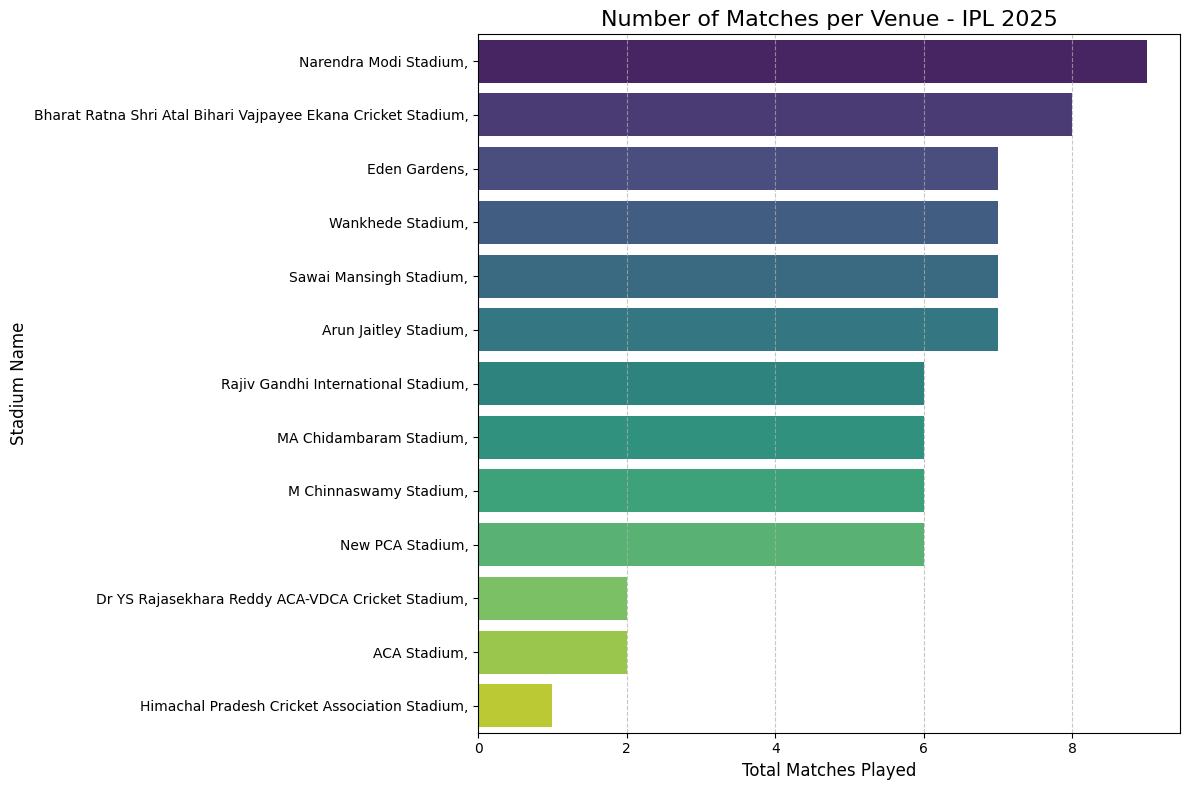

In [8]:
import warnings
warnings.filterwarnings('ignore')
venue_counts = data['Venue'].value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(
    x=venue_counts.values, 
    y=venue_counts.index, 
    palette='viridis'
)
plt.title('Number of Matches per Venue - IPL 2025', fontsize=16)
plt.xlabel('Total Matches Played', fontsize=12)
plt.ylabel('Stadium Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analyze Winning Margin Type

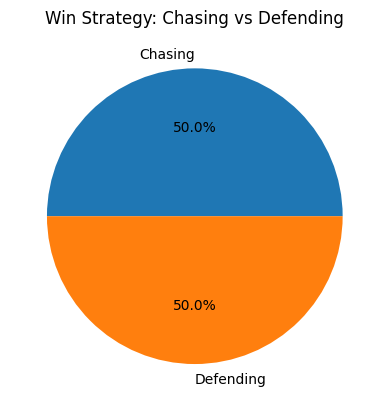

In [22]:
data['winner'] = data['winner'].str.title().str.strip()
data['win_type'] = data['winning_margin'].apply(lambda x: 'Chasing' if 'WICKETS' in str(x).upper() else 'Defending')
data['win_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Win Strategy: Chasing vs Defending')
plt.show()

### Extract only the runs from 'Team 1 Score'

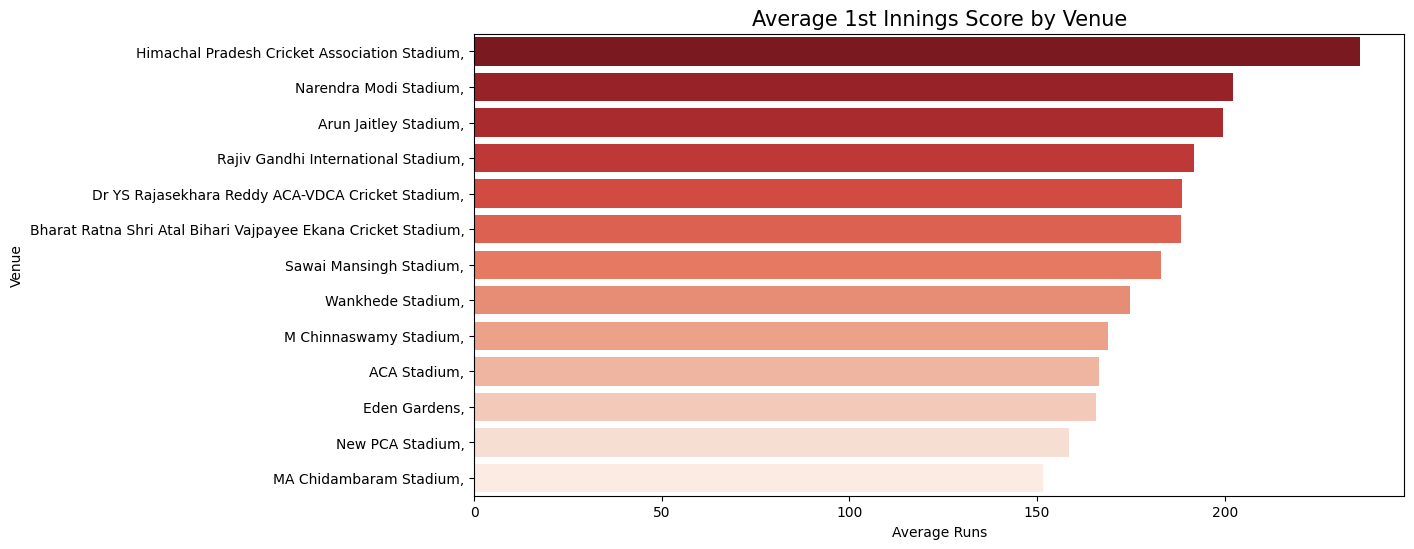

In [9]:
import warnings
warnings.filterwarnings('ignore')
data['team1_runs'] = data['Team 1 Score'].str.split('/').str[0].astype(float)
venue_avg_score = data.groupby('Venue')['team1_runs'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=venue_avg_score.values, y=venue_avg_score.index, palette="Reds_r")
plt.title('Average 1st Innings Score by Venue', fontsize=15)
plt.xlabel('Average Runs')
plt.ylabel('Venue')
plt.show()

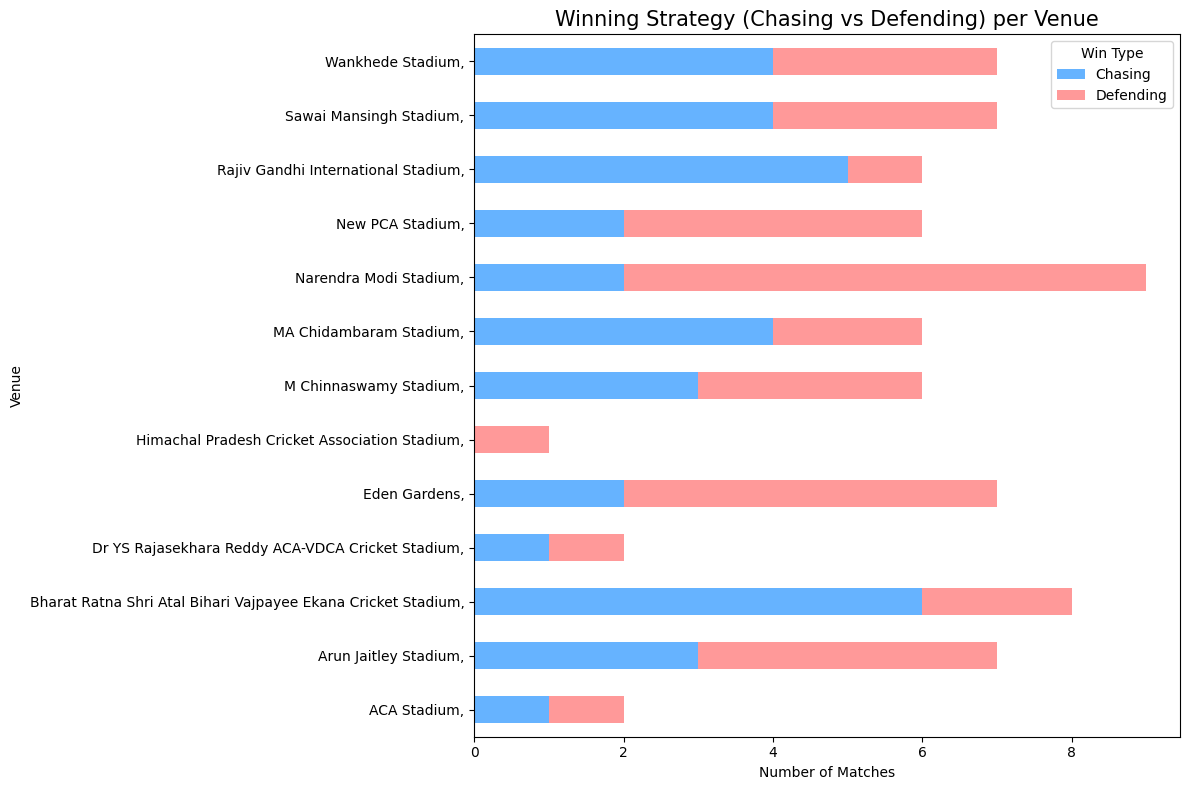

In [25]:
venue_win_type = pd.crosstab(data['Venue'], data['win_type'])
venue_win_type.plot(kind='barh', stacked=True, figsize=(12, 8), color=['#66b3ff', '#ff9999'])
plt.title('Winning Strategy (Chasing vs Defending) per Venue', fontsize=15)
plt.xlabel('Number of Matches')
plt.legend(title='Win Type')
plt.tight_layout()
plt.show()

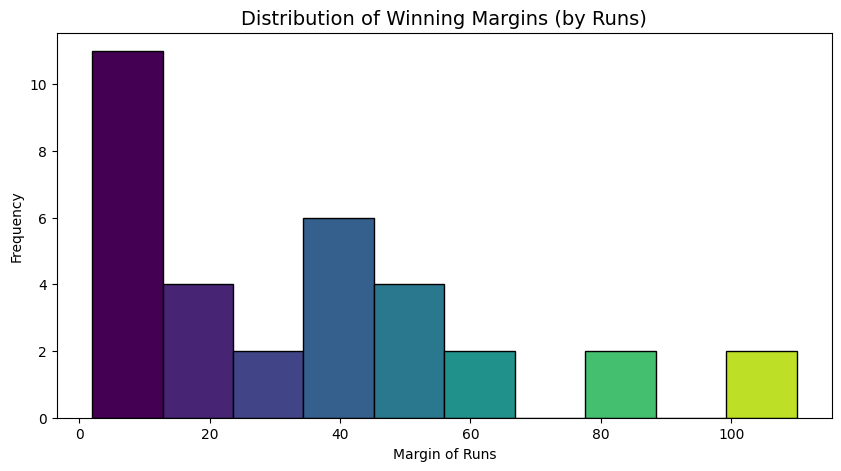

In [33]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(runs_margin, bins=10, )
cmap = plt.cm.viridis
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(cmap(i / len(ax.patches)))
plt.title('Distribution of Winning Margins (by Runs)', fontsize=14)
plt.xlabel('Margin of Runs')
plt.ylabel('Frequency')
plt.show()